<a href="https://colab.research.google.com/github/hlee960/CSE6414ProjectCLT/blob/main/HW10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install orbit-ml neuralforecast -q

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from orbit.models import DLT
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM#
from neuralforecast.losses.pytorch import MAE, MSE, DistributionLoss

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.0/287.0 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.2/447.2 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 43.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into ac

                        ds             y
count                14592  14592.000000
mean   2016-08-30 23:30:00     45.052906
min    2015-11-01 00:00:00      5.000000
25%    2016-03-31 23:45:00     27.000000
50%    2016-08-30 23:30:00     40.000000
75%    2017-01-29 23:15:00     59.000000
max    2017-06-30 23:00:00    156.000000
std                    NaN     23.008345


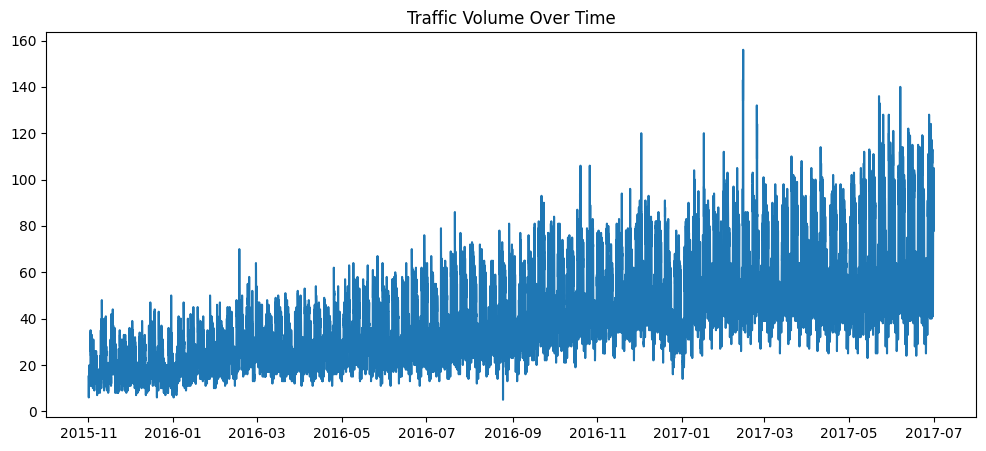

In [6]:
# Part 1: Load Data

df = pd.read_csv("junction1_data.csv")

df["ds"] = pd.to_datetime(df["DateTime"], errors="coerce")
df = df.dropna(subset=["ds"])
df = df.sort_values("ds")

df = df[["ds", "Vehicles"]].rename(columns={"Vehicles": "y"})
df["unique_id"] = "J1"

print(df.describe())

plt.figure(figsize=(12,5))
plt.plot(df["ds"], df["y"])
plt.title("Traffic Volume Over Time")
plt.show()

# Split
h = 168
train = df.iloc[:-h]
test = df.iloc[-h:]

# Metric

def calc_metric(a, p):
    a = np.array(a)
    p = np.array(p)
    return {
        "MAE": np.mean(np.abs(a-p)),
        "MAPE": np.mean(np.abs((a-p)/a)),
        "MSPE": np.mean(((a-p)/a)**2),
        "PM": np.mean(np.sign(np.diff(a)) == np.sign(np.diff(p)))
    }

2026-04-24 03:10:41 - orbit - INFO - Sampling (CmdStanPy) with chains: 4, cores: 2, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.
INFO:orbit:Sampling (CmdStanPy) with chains: 4, cores: 2, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.


chain 1:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

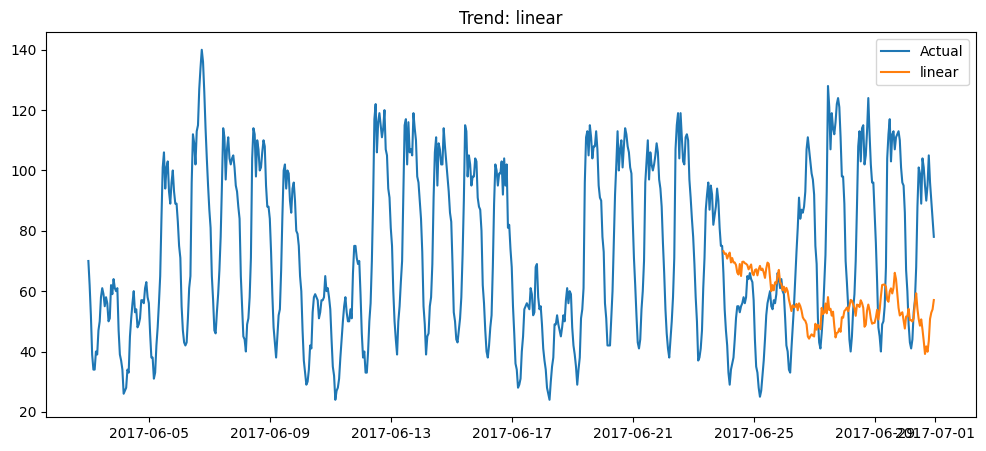

2026-04-24 03:34:25 - orbit - INFO - Sampling (CmdStanPy) with chains: 4, cores: 2, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.
INFO:orbit:Sampling (CmdStanPy) with chains: 4, cores: 2, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.


chain 1:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

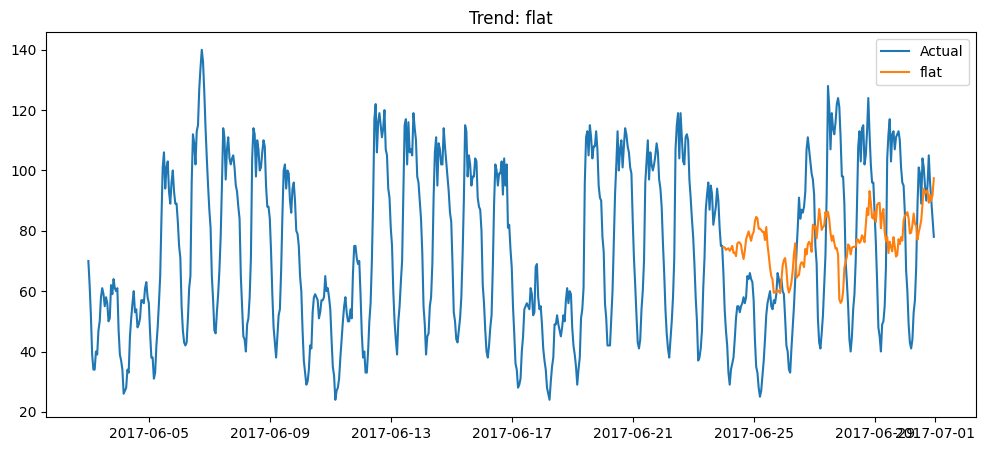

2026-04-24 03:59:58 - orbit - INFO - Sampling (CmdStanPy) with chains: 4, cores: 2, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.
INFO:orbit:Sampling (CmdStanPy) with chains: 4, cores: 2, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.


chain 1:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

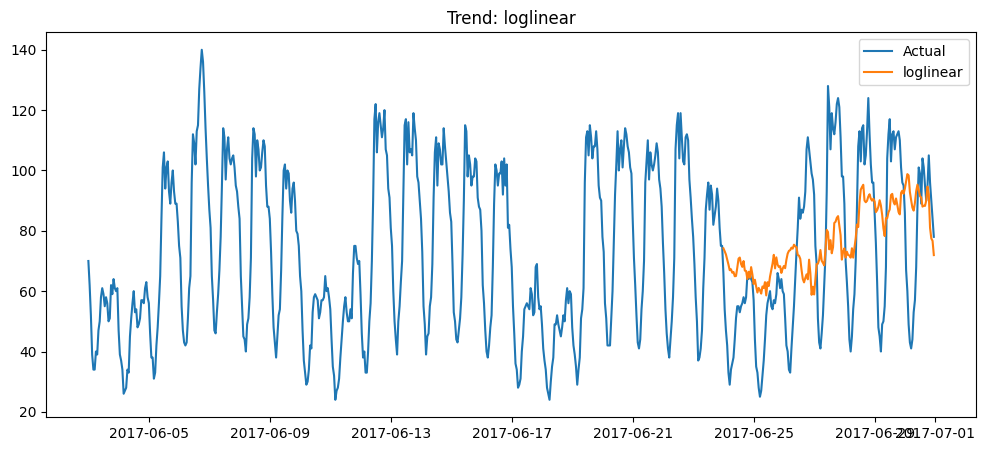

2026-04-24 04:37:02 - orbit - INFO - Sampling (CmdStanPy) with chains: 4, cores: 2, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.
INFO:orbit:Sampling (CmdStanPy) with chains: 4, cores: 2, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.


chain 1:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

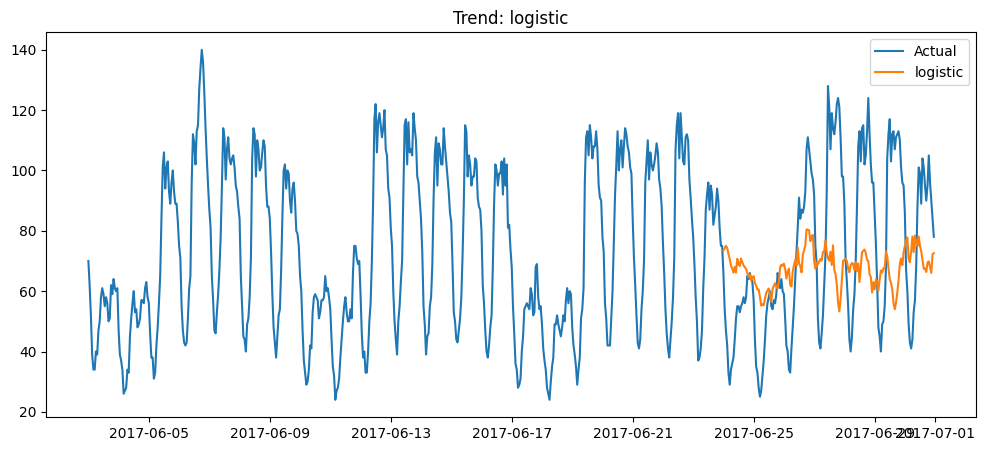

       Trend        MAE      MAPE      MSPE        PM
0     linear  29.829781  0.396411  0.243123  0.413174
1       flat  24.287171  0.412612  0.320585  0.497006
2  loglinear  20.618741  0.349434  0.225304  0.502994
3   logistic  23.518010  0.347213  0.189321  0.491018


In [3]:
# Part 2a
trends = ["linear", "flat", "loglinear", "logistic"]
res_2a = []

for t in trends:
    model = DLT(
        response_col="y",
        date_col="ds",
        global_trend_option=t
    )

    model.fit(train)
    pred = model.predict(test)["prediction"].values

    m = calc_metric(test["y"], pred)
    res_2a.append([t, m["MAE"], m["MAPE"], m["MSPE"], m["PM"]])

    past = df.iloc[-(168+21*24):-168]
    plot_df = pd.concat([past, test])

    plt.figure(figsize=(12,5))
    plt.plot(plot_df["ds"], plot_df["y"], label="Actual")
    plt.plot(test["ds"], pred, label=t)
    plt.title(f"Trend: {t}")
    plt.legend()
    plt.show()

print(pd.DataFrame(res_2a, columns=["Trend","MAE","MAPE","MSPE","PM"]))

In [5]:
configs = [
    ("None", None),
    ("Daily", 24),
    ("Weekly", 168)
]

res_2b = []

for name, s in configs:

    model = DLT(
        response_col="y",
        date_col="ds",
        global_trend_option="loglinear",
        seasonality=s
    )

    model.fit(train)
    pred = model.predict(test)["prediction"].values

    m = calc_metric(test["y"], pred)
    res_2b.append([name, m["MAE"], m["MAPE"], m["MSPE"], m["PM"]])

print(pd.DataFrame(res_2b, columns=["Season","MAE","MAPE","MSPE","PM"]))

2026-04-24 05:47:02 - orbit - INFO - Sampling (CmdStanPy) with chains: 4, cores: 2, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.
INFO:orbit:Sampling (CmdStanPy) with chains: 4, cores: 2, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.


chain 1:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

...

chain 1:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

                                                                                                                                                                                                                                                                                                                                
   Season        MAE      MAPE      MSPE        PM
0    None  20.618741  0.349434  0.225304  0.502994
1   Daily  16.175887  0.278042  0.145169  0.832335
2  Weekly  15.542936  0.244735  0.096966  0.844311


In [10]:
# Part 3a
inputs = [24,48,72,168]
res_3a = []

for i in inputs:

    model = LSTM(
        input_size=i,
        h=h,
        max_steps=300
    )

    nf = NeuralForecast(models=[model], freq="H")
    nf.fit(df=train)

    pred_df = nf.predict()
    pred = pred_df["LSTM"].values

    m = calc_metric(test["y"].values, pred)
    res_3a.append([i, m["MAE"], m["MAPE"], m["MSPE"], m["PM"]])

print(pd.DataFrame(res_3a, columns=["Input","MAE","MAPE","MSPE","PM"]))

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name              ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss              │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train      │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler            │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ hist_encoder      │ LSTM          │  199 K │ train │     0 │
│ 4 │ mlp_decoder       │ MLP           │ 16.6 K │ train │     0 │
│ 5 │ upsample_sequence │ Linear        │  4.2 K │ train │     0 │
└───┴───────────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 220 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 220 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=300` reached.


...

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=300` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

   Input        MAE      MAPE      MSPE        PM
0     24  16.018787  0.212624  0.062881  0.754491
1     48  12.064711  0.173007  0.046090  0.802395
2     72   9.367766  0.133506  0.028415  0.832335
3    168   4.727375  0.066304  0.008188  0.862275


In [12]:
# Part 3b: Scaling
scalers = ["identity", "standard", "robust"]
res_3b = []

for s in scalers:

    model = LSTM(
        input_size=72,
        h=h,
        scaler_type=s,
        max_steps=300
    )

    nf = NeuralForecast(models=[model], freq="H")
    nf.fit(df=train)

    pred_df = nf.predict()
    pred = pred_df["LSTM"].values

    m = calc_metric(test["y"].values, pred)
    res_3b.append([s, m["MAE"], m["MAPE"], m["MSPE"], m["PM"]])

print(pd.DataFrame(res_3b, columns=["Scaler","MAE","MAPE","MSPE","PM"]))

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name              ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss              │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train      │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler            │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ hist_encoder      │ LSTM          │  199 K │ train │     0 │
│ 4 │ mlp_decoder       │ MLP           │ 16.6 K │ train │     0 │
│ 5 │ upsample_sequence │ Linear        │ 12.3 K │ train │     0 │
└───┴───────────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 228 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 228 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=300` reached.


...

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=300` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

     Scaler        MAE      MAPE      MSPE        PM
0  identity  15.518717  0.240471  0.093297  0.766467
1  standard   9.869184  0.138891  0.032983  0.826347
2    robust   9.367766  0.133506  0.028415  0.832335


In [14]:
# Part 3c: Loss Function
losses = [DistributionLoss("Normal"), MAE(), MSE()]
res_3c = []

for l in losses:

    model = LSTM(
        input_size=72,
        h=h,
        loss=l,
        max_steps=300
    )

    nf = NeuralForecast(models=[model], freq="H")
    nf.fit(df=train)

    pred_df = nf.predict()

    pred = pred_df["LSTM"].values if "LSTM" in pred_df.columns else pred_df.iloc[:, -1].values

    m = calc_metric(test["y"].values, pred)
    res_3c.append([str(l), m["MAE"], m["MAPE"], m["MSPE"], m["PM"]])

print(pd.DataFrame(res_3c, columns=["Loss","MAE","MAPE","MSPE","PM"]))

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name              ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss              │ DistributionLoss │      5 │ train │     0 │
│ 1 │ padder_train      │ ConstantPad1d    │      0 │ train │     0 │
│ 2 │ scaler            │ TemporalNorm     │      0 │ train │     0 │
│ 3 │ hist_encoder      │ LSTM             │  199 K │ train │     0 │
│ 4 │ mlp_decoder       │ MLP              │ 16.8 K │ train │     0 │
│ 5 │ upsample_sequence │ Linear           │ 12.3 K │ train │     0 │
└───┴───────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 228 K                                                                                            
Non-trainable params: 5                                                                                            
Total params: 228 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=300` reached.


...

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=300` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

                 Loss        MAE      MAPE      MSPE        PM
0  DistributionLoss()  10.451219  0.151428  0.040894  0.790419
1               MAE()   9.367766  0.133506  0.028415  0.832335
2               MSE()   9.184347  0.132284  0.028744  0.844311


In [16]:
# Part 3d: Architecture
configs = [(1,64),(2,128),(3,256)]
res_3d = []

for layers, hidden in configs:

    model = LSTM(
        input_size=72,
        h=h,
        encoder_n_layers=layers,
        encoder_hidden_size=hidden,
        max_steps=300
    )

    nf = NeuralForecast(models=[model], freq="H")
    nf.fit(df=train)

    pred_df = nf.predict()

    pred = pred_df["LSTM"].values

    m = calc_metric(test["y"].values, pred)
    res_3d.append([layers, hidden, m["MAE"], m["MAPE"], m["MSPE"], m["PM"]])

print(pd.DataFrame(res_3d, columns=["Layers","Hidden","MAE","MAPE","MSPE","PM"]))

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name              ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss              │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train      │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler            │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ hist_encoder      │ LSTM          │ 17.2 K │ train │     0 │
│ 4 │ mlp_decoder       │ MLP           │  8.4 K │ train │     0 │
│ 5 │ upsample_sequence │ Linear        │ 12.3 K │ train │     0 │
└───┴───────────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 37.9 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 37.9 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=300` reached.


...

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=300` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

   Layers  Hidden       MAE      MAPE      MSPE        PM
0       1      64  8.352543  0.117127  0.022102  0.802395
1       2     128  9.367766  0.133506  0.028415  0.832335
2       3     256  9.365362  0.127887  0.026948  0.808383


2026-04-24 11:18:06 - orbit - INFO - Sampling (CmdStanPy) with chains: 4, cores: 2, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.
INFO:orbit:Sampling (CmdStanPy) with chains: 4, cores: 2, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.


chain 1:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

...

Trainable params: 228 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 228 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=300` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

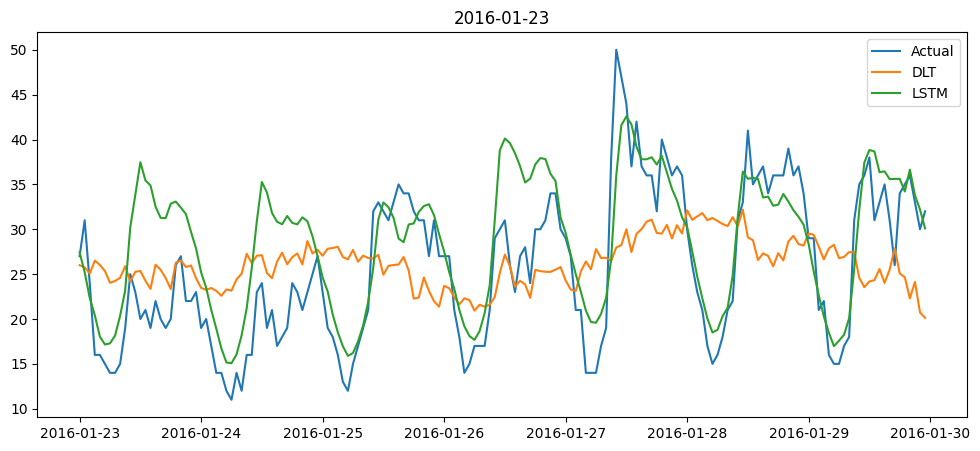

2026-04-24 11:22:38 - orbit - INFO - Sampling (CmdStanPy) with chains: 4, cores: 2, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.
INFO:orbit:Sampling (CmdStanPy) with chains: 4, cores: 2, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.


chain 1:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

...

Trainable params: 228 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 228 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=300` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

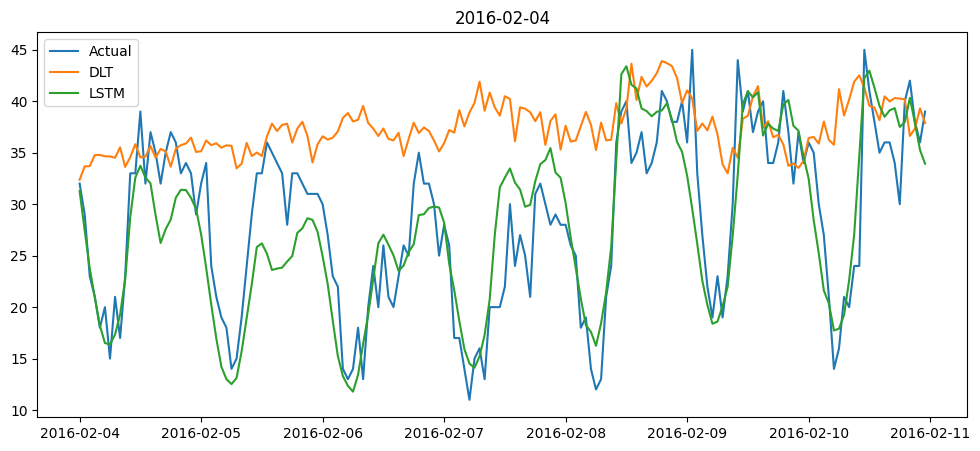

2026-04-24 11:27:26 - orbit - INFO - Sampling (CmdStanPy) with chains: 4, cores: 2, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.
INFO:orbit:Sampling (CmdStanPy) with chains: 4, cores: 2, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.


chain 1:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

...

Trainable params: 228 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 228 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=300` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

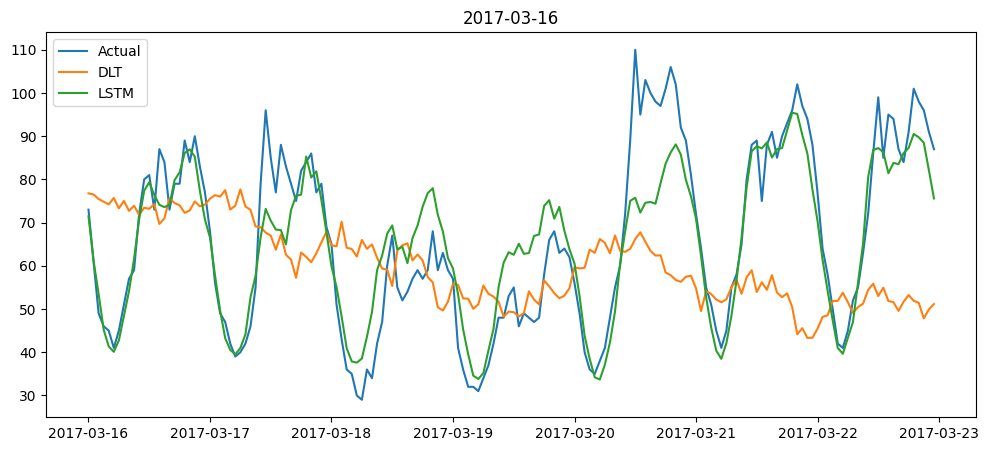

2026-04-24 12:01:50 - orbit - INFO - Sampling (CmdStanPy) with chains: 4, cores: 2, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.
INFO:orbit:Sampling (CmdStanPy) with chains: 4, cores: 2, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.


chain 1:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

...

Trainable params: 228 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 228 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=300` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

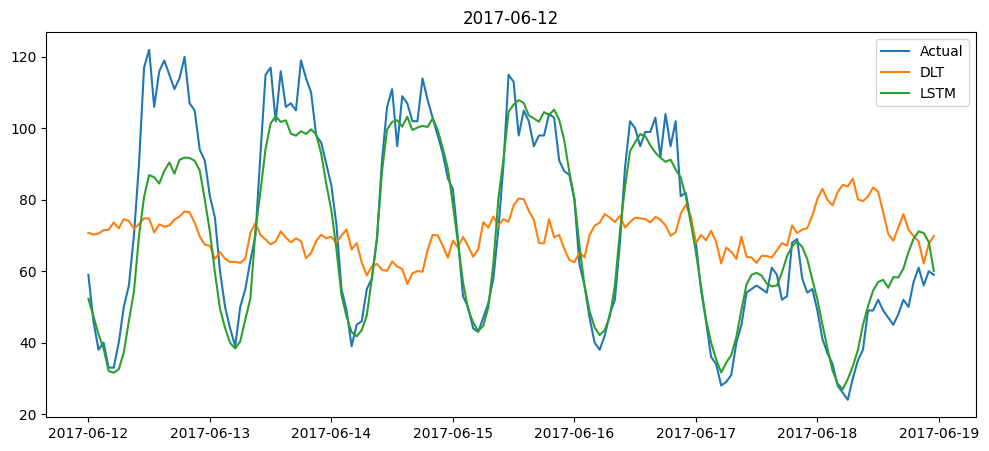

2026-04-24 12:42:06 - orbit - INFO - Sampling (CmdStanPy) with chains: 4, cores: 2, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.
INFO:orbit:Sampling (CmdStanPy) with chains: 4, cores: 2, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.


chain 1:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

...

Trainable params: 228 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 228 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=300` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

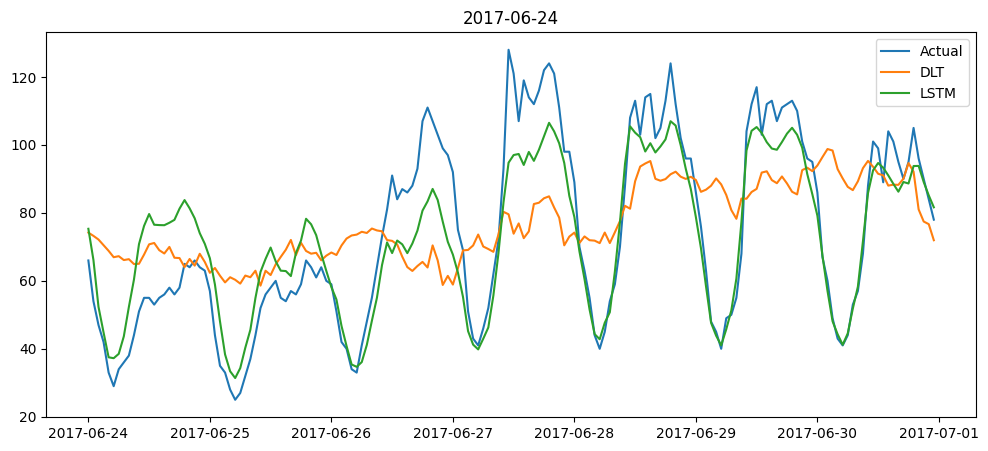

  Model        Date        MAE      MAPE      MSPE        PM
0   DLT  2016-01-23   7.212732  0.330135  0.177626  0.443114
1  LSTM  2016-01-23   4.533249  0.204331  0.078462  0.586826
2   DLT  2016-02-04   9.737875  0.484360  0.520520  0.461078
3  LSTM  2016-02-04   3.716381  0.139397  0.031055  0.622754
4   DLT  2017-03-16  19.736849  0.316460  0.158660  0.437126
5  LSTM  2017-03-16   6.898426  0.108985  0.021372  0.778443
6   DLT  2017-06-12  25.467304  0.424568  0.331041  0.485030
7  LSTM  2017-06-12   6.827437  0.093153  0.014307  0.748503
8   DLT  2017-06-24  20.618741  0.349434  0.225304  0.502994
9  LSTM  2017-06-24   9.367766  0.133506  0.028415  0.832335


In [18]:
# Part 4a: Multi Period Comparison
dates = ["2016-01-23","2016-02-04","2017-03-16","2017-06-12","2017-06-24"]
res_4a = []

for d in dates:

    train_d = df[df["ds"] < d]
    test_d = df[df["ds"] >= d].iloc[:168]

    if len(train_d) < 200 or len(test_d) < 168:
        continue

    # DLT
    dlt = DLT(response_col="y", date_col="ds", global_trend_option="loglinear")
    dlt.fit(train_d)
    pred_dlt = dlt.predict(test_d)["prediction"].values

    # LSTM
    model = LSTM(input_size=72, h=168, max_steps=300)
    nf = NeuralForecast(models=[model], freq="H")
    nf.fit(df=train_d)

    pred_df = nf.predict()
    pred_lstm = pred_df["LSTM"].values

    # metrics
    m1 = calc_metric(test_d["y"].values, pred_dlt)
    m2 = calc_metric(test_d["y"].values, pred_lstm)

    res_4a.append(["DLT", d, m1["MAE"], m1["MAPE"], m1["MSPE"], m1["PM"]])
    res_4a.append(["LSTM", d, m2["MAE"], m2["MAPE"], m2["MSPE"], m2["PM"]])

    # plot
    plt.figure(figsize=(12,5))
    plt.plot(test_d["ds"], test_d["y"], label="Actual")
    plt.plot(test_d["ds"], pred_dlt, label="DLT")
    plt.plot(test_d["ds"], pred_lstm, label="LSTM")
    plt.title(d)
    plt.legend()
    plt.show()

res_4a_df = pd.DataFrame(res_4a, columns=["Model","Date","MAE","MAPE","MSPE","PM"])
print(res_4a_df)

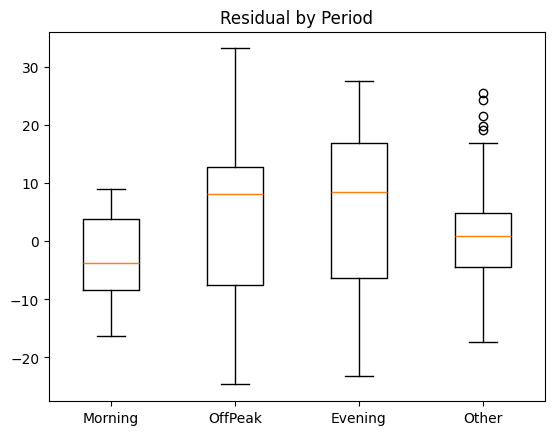

In [19]:
# Part 4b: Time-of-Day Residual
test["hour"] = test["ds"].dt.hour

def period(h):
    if 7<=h<=9: return "Morning"
    elif 10<=h<=15: return "OffPeak"
    elif 16<=h<=19: return "Evening"
    else: return "Other"

test["period"] = test["hour"].apply(period)

residual = test["y"].values - pred_lstm[:len(test)]

plt.boxplot([residual[test["period"]==p] for p in ["Morning","OffPeak","Evening","Other"]],
            labels=["Morning","OffPeak","Evening","Other"])
plt.title("Residual by Period")
plt.show()

In [20]:
print(res_4a_df.groupby("Model")[["MAE","MAPE","MSPE","PM"]].mean())

             MAE      MAPE      MSPE        PM
Model                                         
DLT    16.554700  0.380992  0.282630  0.465868
LSTM    6.268652  0.135874  0.034722  0.713772


In [7]:
## Part 5: Model Comparison and Improvement

date_list = [
  "2016-01-23",
  "2016-02-04",
  "2017-03-16",
  "2017-06-12",
  "2017-06-24"
]

res_4a = []

for d in date_list:

    train_d = df[df["ds"] < d]
    test_d  = df[df["ds"] >= d].iloc[:168]

    if len(train_d) < 200 or len(test_d) < 168:
        continue

    # DLT
    dlt = DLT(response_col="y", date_col="ds", global_trend_option="loglinear")
    dlt.fit(train_d)
    pred_dlt = dlt.predict(test_d)["prediction"].values

    # LSTM
    model = LSTM(input_size=72, h=168, max_steps=300)
    nf = NeuralForecast(models=[model], freq="H")
    nf.fit(df=train_d)

    pred_df = nf.predict()
    pred_lstm = pred_df["LSTM"].values

    # metrics
    m1 = calc_metric(test_d["y"].values, pred_dlt)
    m2 = calc_metric(test_d["y"].values, pred_lstm)

    res_4a.append(["DLT", d, m1["MAE"], m1["MAPE"], m1["MSPE"], m1["PM"]])
    res_4a.append(["LSTM", d, m2["MAE"], m2["MAPE"], m2["MSPE"], m2["PM"]])

res_4a_df = pd.DataFrame(res_4a, columns=["Model","Date","MAE","MAPE","MSPE","PM"])

print(res_4a_df)

print(res_4a_df.groupby("Model")[["MAE","MAPE","MSPE","PM"]].mean())

2026-04-25 01:23:44 - orbit - INFO - Sampling (CmdStanPy) with chains: 4, cores: 2, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.
INFO:orbit:Sampling (CmdStanPy) with chains: 4, cores: 2, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.


chain 1:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/250 [00:00<?, ?it/s, (Warmup)]

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=300` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

  Model        Date        MAE      MAPE      MSPE        PM
0   DLT  2016-01-23   7.212732  0.330135  0.177626  0.443114
1  LSTM  2016-01-23   4.533249  0.204331  0.078462  0.586826
2   DLT  2016-02-04   9.737875  0.484360  0.520520  0.461078
3  LSTM  2016-02-04   3.716381  0.139397  0.031055  0.622754
4   DLT  2017-03-16  19.736849  0.316460  0.158660  0.437126
5  LSTM  2017-03-16   6.898426  0.108985  0.021372  0.778443
6   DLT  2017-06-12  25.467304  0.424568  0.331041  0.485030
7  LSTM  2017-06-12   6.827437  0.093153  0.014307  0.748503
8   DLT  2017-06-24  20.618741  0.349434  0.225304  0.502994
9  LSTM  2017-06-24   9.367766  0.133506  0.028415  0.832335
             MAE      MAPE      MSPE        PM
Model                                         
DLT    16.554700  0.380992  0.282630  0.465868
LSTM    6.268652  0.135874  0.034722  0.713772
